# 🤖 Instagram Performance Analysis — Travel Mex Tours
## Notebook 03: Machine Learning — Performance Prediction

**Author:** Maria Garcia Sehara  
**Project:** Social Media Analytics — Travel Mex Tours  
**Platform:** Instagram  

---

### Objective
Build models to **predict Performance Score and Engagement Rate before publishing**.

### Key Methodological Decisions

**1. Two model sets:**
- **Full models (Sections 4-5):** Use all available features for maximum R². Good for understanding what drives performance historically.
- **Predictor model (Section 8):** Uses only pre-publication features. Honest prediction tool for the agency.

**2. Feature selection for predictor:**

| Feature | Included | Reason |
|---------|----------|--------|
| Content Type | ✅ | Known before publishing |
| Weekday | ✅ | Known before publishing |
| Time Slot | ✅ | Known before publishing |
| Month | ✅ | Known before publishing |
| Reach | ✅ | Default: median=31 (mode only 6.5% — not representative) |
| Views | ✅ | Default: median=84 (mode only 4.1% — not representative) |
| Likes | ✅ | Default: mode=4 (24.4% — representative) |
| Saves | ❌ | 82% zeros — no variation |
| Comments | ❌ | 93% zeros — no variation |
| Shares | ❌ | 74% zeros — no variation |
| Follows | ❌ | 99% zeros — no variation |

**3. Why median for reach/views and mode for likes?**
The mode is only valid as a default when it represents a meaningful share of posts (≥15%).
Reach mode=18 appears in only 6.5% of posts — not representative. Median=31 is more robust.
Likes mode=4 appears in 24.4% of posts — representative and valid.


## 1. Setup & Data Load

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

BRAND_BLUE   = "#1877F2"
BRAND_PURPLE = "#833AB4"
BRAND_PINK   = "#E1306C"
PALETTE      = [BRAND_BLUE, BRAND_PURPLE, BRAND_PINK, "#FCAF45"]

RANDOM_STATE = 42
TEST_SIZE    = 0.20
BENCHMARK_ER = 5.0
FIGURES_PATH = Path("../../outputs/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print("✅ Setup complete")


✅ Setup complete


In [2]:
from load_data import load_instagram_csv
from preprocessing import preprocess_df

DATA_DIR  = Path("../../data/instagram/")
csv_files = sorted(DATA_DIR.glob("*.csv"), key=lambda f: f.stat().st_mtime, reverse=True)
if not csv_files:
    raise FileNotFoundError("No CSV found in data/instagram/")

df_raw   = load_instagram_csv(csv_files[0])
df, meta = preprocess_df(df_raw)

er_col        = meta["engagement_rate_col"]
ps_col        = meta["performance_score_col"]
type_col      = meta.get("type_col")
time_slot_col = meta.get("time_slot_col")

print(f"✅ Data loaded → {len(df)} posts")
print(f"   Primary target   : {ps_col}  (Performance Score 0-100)")
print(f"   Secondary target : {er_col}  (Engagement Rate %)")
print(f"   Avg Score        : {meta['avg_performance_score']}/100")
print(f"   Avg ER           : {meta['avg_engagement_rate']}%")


✅ Loaded: InstagramData.csv  |  125 rows × 18 cols  |  UNKNOWN
✅ Preprocessing completed!
   → Date column            : publish_time
   → ER calculated via      : REACH
   → Avg ER                 : 15.36%
   → Avg Performance Score  : 30.25/100
   → vs Maximum Potential   : High=0 | Medium=46 | Low=79
   → vs Other Posts         : Above Avg=31 | Avg=60 | Below Avg=34
   → Time slots:
      🌅 Early Morning (6-9): 89 posts | avg ER 15.77%
      ☀️ Late Morning (10-12): 16 posts | avg ER 14.29%
      🌤️ Afternoon (13-17): 16 posts | avg ER 13.38%
✅ Data loaded → 125 posts
   Primary target   : performance_score  (Performance Score 0-100)
   Secondary target : engagement_rate_pct  (Engagement Rate %)
   Avg Score        : 30.25/100
   Avg ER           : 15.36%


## 2. Feature Analysis — Understanding Our Data Before Modeling

In [3]:
# Analyze mode representativity for all numeric features
print("MODE REPRESENTATIVITY ANALYSIS")
print("Rule: if mode appears in <15% of posts → use median as default")
print()

num_keys = ["reach_col","views_col","likes_col","comments_col",
            "saves_col","shares_col","follows_col"]

feature_analysis = {}
for key in num_keys:
    col = meta.get(key)
    if not col or col not in df.columns:
        continue
    mode_val   = int(df[col].mode()[0])
    mode_count = int((df[col] == mode_val).sum())
    mode_pct   = mode_count / df[col].notna().sum() * 100
    median_val = int(df[col].median())
    zero_pct   = (df[col] == 0).mean() * 100

    flag       = "✅ representative" if mode_pct >= 15 else "⚠️  low representativity"
    exclude    = "❌ EXCLUDE" if zero_pct >= 70 else ""

    feature_analysis[col] = {
        "mode": mode_val, "mode_pct": mode_pct,
        "median": median_val, "zero_pct": zero_pct,
        "use_median": mode_pct < 15,
        "exclude": zero_pct >= 70
    }

    print(f"   {col:20s}: mode={mode_val:4d} ({mode_pct:.1f}%) | "
          f"median={median_val:4d} | zeros={zero_pct:.0f}%  {flag} {exclude}")

print()
print("→ Features with ≥70% zeros excluded from predictor (no variation)")
print("→ Features with mode <15% use median as default")


MODE REPRESENTATIVITY ANALYSIS
Rule: if mode appears in <15% of posts → use median as default

   reach               : mode=  18 (6.5%) | median=  31 | zeros=0%  ⚠️  low representativity 
   views               : mode=  58 (4.1%) | median=  84 | zeros=0%  ⚠️  low representativity 
   likes               : mode=   4 (24.4%) | median=   4 | zeros=0%  ✅ representative 
   comments            : mode=   0 (92.7%) | median=   0 | zeros=91%  ✅ representative ❌ EXCLUDE
   saves               : mode=   0 (82.1%) | median=   0 | zeros=81%  ✅ representative ❌ EXCLUDE
   shares              : mode=   0 (74.0%) | median=   0 | zeros=73%  ✅ representative ❌ EXCLUDE
   follows             : mode=   0 (99.2%) | median=   0 | zeros=98%  ✅ representative ❌ EXCLUDE

→ Features with ≥70% zeros excluded from predictor (no variation)
→ Features with mode <15% use median as default


## 3. Feature Selection

In [4]:
# Full model features (for historical analysis)
all_num_keys  = ["reach_col","views_col","likes_col","comments_col",
                 "saves_col","shares_col","follows_col"]
all_num_feats = [meta[k] for k in all_num_keys if meta.get(k) and meta[k] in df.columns]

cat_feats = []
if type_col and type_col in df.columns:             cat_feats.append(type_col)
if "weekday" in df.columns:                         cat_feats.append("weekday")
if time_slot_col and time_slot_col in df.columns:   cat_feats.append(time_slot_col)
if "month" in df.columns:                           cat_feats.append("month")

all_feats = all_num_feats + cat_feats

# Predictor features (pre-publication only, no zero-dominated)
PREDICTOR_NUM_FEATS = []
PREDICTOR_DEFAULTS  = {}

for col, info in feature_analysis.items():
    if info["exclude"]:
        continue   # skip zero-dominated features
    PREDICTOR_NUM_FEATS.append(col)
    # Use median if mode not representative, else mode
    PREDICTOR_DEFAULTS[col] = info["median"] if info["use_median"] else info["mode"]

PREDICTOR_CAT_FEATS = cat_feats.copy()
PREDICTOR_ALL_FEATS = PREDICTOR_NUM_FEATS + PREDICTOR_CAT_FEATS

print("FULL MODEL features (historical analysis):")
print(f"   Numeric     ({len(all_num_feats)}): {all_num_feats}")
print(f"   Categorical ({len(cat_feats)}): {cat_feats}")

print()
print("PREDICTOR features (pre-publication only):")
print(f"   Numeric     ({len(PREDICTOR_NUM_FEATS)}): {PREDICTOR_NUM_FEATS}")
print(f"   Categorical ({len(PREDICTOR_CAT_FEATS)}): {PREDICTOR_CAT_FEATS}")
print()
print("PREDICTOR defaults:")
for col, val in PREDICTOR_DEFAULTS.items():
    info = feature_analysis[col]
    src  = "median" if info["use_median"] else "mode"
    print(f"   {col:20s}: {val:4d}  ({src})")


FULL MODEL features (historical analysis):
   Numeric     (7): ['reach', 'views', 'likes', 'comments', 'saves', 'shares', 'follows']
   Categorical (4): ['post_type', 'weekday', 'time_slot', 'month']

PREDICTOR features (pre-publication only):
   Numeric     (3): ['reach', 'views', 'likes']
   Categorical (4): ['post_type', 'weekday', 'time_slot', 'month']

PREDICTOR defaults:
   reach               :   31  (median)
   views               :   84  (median)
   likes               :    4  (mode)


In [5]:
# Build model datasets
model_df     = df[all_feats + [ps_col, er_col]].dropna()
predictor_df = df[PREDICTOR_ALL_FEATS + [ps_col, er_col]].dropna()

print(f"Full model dataset   : {len(model_df)} rows")
print(f"Predictor dataset    : {len(predictor_df)} rows")

if len(model_df) < 30:
    raise ValueError(f"Only {len(model_df)} rows — need ≥30.")

X    = model_df[all_feats]
y_ps = model_df[ps_col]
y_er = model_df[er_col]

X_train, X_test, y_train_ps, y_test_ps = train_test_split(
    X, y_ps, test_size=TEST_SIZE, random_state=RANDOM_STATE)
_, _, y_train_er, y_test_er = train_test_split(
    X, y_er, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"\nTrain: {len(X_train)} rows | Test: {len(X_test)} rows")


Full model dataset   : 121 rows
Predictor dataset    : 121 rows

Train: 96 rows | Test: 25 rows


## 4. Full Model Pipeline

In [6]:
def build_preprocessor(num_feats, cat_feats):
    transformers = [("num", StandardScaler(), num_feats)]
    if cat_feats:
        transformers.append(
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",
                                  sparse_output=False), cat_feats))
    return ColumnTransformer(transformers, remainder="drop")

preprocessor = build_preprocessor(all_num_feats, cat_feats)

model_zoo = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0),
    "Random Forest":      RandomForestRegressor(
        n_estimators=400, max_depth=10, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("✅ Pipeline ready")


✅ Pipeline ready


## 5. Train Full Models — Historical Analysis

In [7]:
def train_models(X, X_train, X_test, y_train, y_test, y_full,
                 preprocessor, model_zoo, cv, label):
    results, pipelines = {}, {}
    print(f"Training models for {label}...\n")
    for name, model in model_zoo.items():
        pipe = Pipeline([("pre", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)
        y_pred    = pipe.predict(X_test)
        cv_scores = cross_val_score(pipe, X, y_full, cv=cv, scoring="r2", n_jobs=-1)
        results[name] = {
            "R2":        round(float(r2_score(y_test, y_pred)), 4),
            "MAE":       round(float(mean_absolute_error(y_test, y_pred)), 4),
            "RMSE":      round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 4),
            "CV_R2":     round(float(cv_scores.mean()), 4),
            "CV_R2_std": round(float(cv_scores.std()), 4),
        }
        pipelines[name] = pipe
        print(f"   {name}")
        print(f"      R²={results[name]['R2']}  MAE=±{results[name]['MAE']}  "
              f"CV R²={results[name]['CV_R2']}±{results[name]['CV_R2_std']}")
    best = max(results, key=lambda x: results[x]["R2"])
    print(f"\n   ⭐ Best: {best}  (R²={results[best]['R2']})")
    return results, pipelines, best

results_ps, pipelines_ps, best_ps = train_models(
    X, X_train, X_test, y_train_ps, y_test_ps, y_ps,
    preprocessor, model_zoo, cv, "Performance Score")

print()

results_er, pipelines_er, best_er = train_models(
    X, X_train, X_test, y_train_er, y_test_er, y_er,
    preprocessor, model_zoo, cv, "Engagement Rate")


Training models for Performance Score...

   Linear Regression
      R²=0.8837  MAE=±3.1245  CV R²=0.7536±0.0969
   Ridge Regression
      R²=0.8625  MAE=±3.4325  CV R²=0.7782±0.0614
   Random Forest
      R²=0.7968  MAE=±4.0789  CV R²=0.7499±0.1347
   Gradient Boosting
      R²=0.9035  MAE=±2.9148  CV R²=0.8923±0.0573

   ⭐ Best: Gradient Boosting  (R²=0.9035)

Training models for Engagement Rate...

   Linear Regression
      R²=0.7843  MAE=±3.005  CV R²=0.4604±0.206
   Ridge Regression
      R²=0.7464  MAE=±3.2892  CV R²=0.5048±0.1698
   Random Forest
      R²=0.7809  MAE=±3.0093  CV R²=0.715±0.15
   Gradient Boosting
      R²=0.8883  MAE=±2.1399  CV R²=0.8661±0.0847

   ⭐ Best: Gradient Boosting  (R²=0.8883)


## 6. Full Model Results

In [8]:
print("PERFORMANCE SCORE — Model Results:")
ps_df = (pd.DataFrame(results_ps).T
           .reset_index().rename(columns={"index":"Model"})
           .sort_values("R2", ascending=False))
display(ps_df.style
    .highlight_max(subset=["R2","CV_R2"], color="#c6efce")
    .highlight_min(subset=["MAE","RMSE"], color="#c6efce")
    .format(precision=4)
    .set_caption("Performance Score — Full Model"))

print("\nENGAGEMENT RATE — Model Results:")
er_df = (pd.DataFrame(results_er).T
           .reset_index().rename(columns={"index":"Model"})
           .sort_values("R2", ascending=False))
display(er_df.style
    .highlight_max(subset=["R2","CV_R2"], color="#c6efce")
    .highlight_min(subset=["MAE","RMSE"], color="#c6efce")
    .format(precision=4)
    .set_caption("Engagement Rate — Full Model"))


PERFORMANCE SCORE — Model Results:


,Model,R2,MAE,RMSE,CV_R2,CV_R2_std
3,Gradient Boosting,0.9035,2.9148,3.6448,0.8923,0.0573
0,Linear Regression,0.8837,3.1245,4.0021,0.7536,0.0969
1,Ridge Regression,0.8625,3.4325,4.3506,0.7782,0.0614
2,Random Forest,0.7968,4.0789,5.2891,0.7499,0.1347



ENGAGEMENT RATE — Model Results:


,Model,R2,MAE,RMSE,CV_R2,CV_R2_std
3,Gradient Boosting,0.8883,2.1399,2.7699,0.8661,0.0847
0,Linear Regression,0.7843,3.0050,3.8491,0.4604,0.2060
2,Random Forest,0.7809,3.0093,3.8792,0.7150,0.1500
1,Ridge Regression,0.7464,3.2892,4.1740,0.5048,0.1698


In [9]:
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["R² — Performance Score",
                                    "R² — Engagement Rate"])

colors_ps = ["#4ade80" if m == best_ps else BRAND_BLUE for m in ps_df["Model"]]
colors_er = ["#4ade80" if m == best_er else BRAND_PURPLE for m in er_df["Model"]]

fig.add_trace(go.Bar(x=ps_df["Model"], y=ps_df["R2"],
    marker_color=colors_ps, text=ps_df["R2"].round(3), textposition="outside"
), row=1, col=1)
fig.add_trace(go.Bar(x=er_df["Model"], y=er_df["R2"],
    marker_color=colors_er, text=er_df["R2"].round(3), textposition="outside"
), row=1, col=2)

fig.update_layout(
    title="Full Model Comparison — Performance Score vs Engagement Rate",
    showlegend=False, yaxis=dict(range=[0,1.15]), yaxis2=dict(range=[0,1.15]),
    plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)",
    font_color="rgba(255,255,255,0.8)"
)
fig.show()


## 7. Feature Importance — What Drives Each Target?

In [10]:
def get_fi(pipelines, best, num_feats, cat_feats):
    for name in [best, "Gradient Boosting", "Random Forest"]:
        if name not in pipelines: continue
        pipe   = pipelines[name]
        fitted = pipe.named_steps["pre"]
        try:
            ohe       = fitted.named_transformers_["cat"]
            cat_names = ohe.get_feature_names_out(cat_feats).tolist()
        except Exception:
            cat_names = []
        all_names   = num_feats + cat_names
        importances = pipe.named_steps["model"].feature_importances_
        if len(importances) == len(all_names):
            fi = pd.DataFrame({"Feature": all_names, "Importance": importances})
            return fi.sort_values("Importance", ascending=False).round(4).reset_index(drop=True)
    return None

fi_ps = get_fi(pipelines_ps, best_ps, all_num_feats, cat_feats)
fi_er = get_fi(pipelines_er, best_er, all_num_feats, cat_feats)

if fi_ps is not None:
    print("Top 5 drivers of PERFORMANCE SCORE:")
    for _, row in fi_ps.head(5).iterrows():
        print(f"   {row['Feature']:30s}: {row['Importance']:.4f}")
print()
if fi_er is not None:
    print("Top 5 drivers of ENGAGEMENT RATE:")
    for _, row in fi_er.head(5).iterrows():
        print(f"   {row['Feature']:30s}: {row['Importance']:.4f}")

if fi_ps is not None and fi_er is not None:
    top_ps = fi_ps.iloc[0]["Feature"]
    top_er = fi_er.iloc[0]["Feature"]
    print()
    if top_ps != top_er:
        print(f"⚠️  Top driver differs: Score→{top_ps} | ER→{top_er}")
        print(f"   Optimizing for ER alone may not maximize overall impact.")
    else:
        print(f"✅ Both targets share top driver: {top_ps}")


Top 5 drivers of PERFORMANCE SCORE:
   reach                         : 0.4813
   likes                         : 0.2967
   views                         : 0.0471
   shares                        : 0.0443
   saves                         : 0.0397

Top 5 drivers of ENGAGEMENT RATE:
   reach                         : 0.4813
   likes                         : 0.2967
   views                         : 0.0471
   shares                        : 0.0443
   saves                         : 0.0397

✅ Both targets share top driver: reach


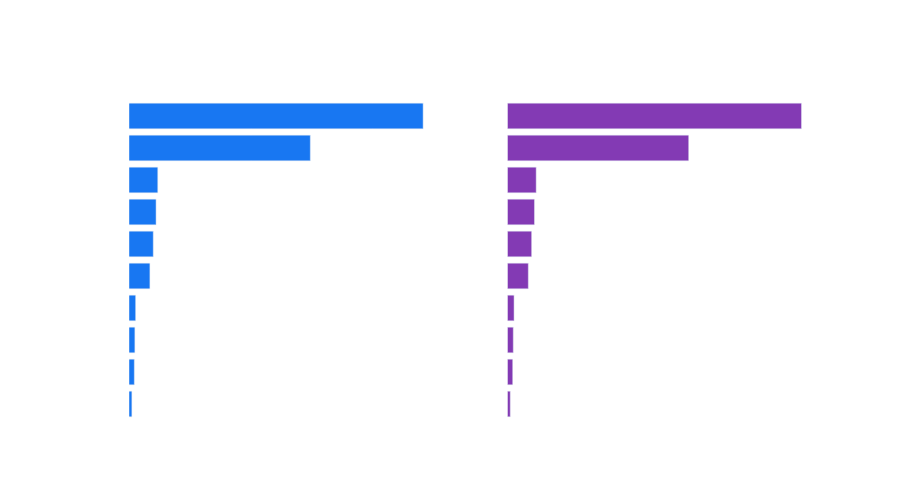

In [11]:
if fi_ps is not None and fi_er is not None:
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=["Drives Performance Score",
                                        "Drives Engagement Rate"])
    top_ps = fi_ps.head(10)
    top_er = fi_er.head(10)
    fig.add_trace(go.Bar(x=top_ps["Importance"], y=top_ps["Feature"],
        orientation="h", marker_color=BRAND_BLUE,
        text=top_ps["Importance"].round(4), textposition="outside"
    ), row=1, col=1)
    fig.add_trace(go.Bar(x=top_er["Importance"], y=top_er["Feature"],
        orientation="h", marker_color=BRAND_PURPLE,
        text=top_er["Importance"].round(4), textposition="outside"
    ), row=1, col=2)
    fig.update_layout(
        title="Feature Importance — Full Model",
        showlegend=False,
        plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)",
        font_color="rgba(255,255,255,0.8)",
        yaxis=dict(categoryorder="total ascending"),
        yaxis2=dict(categoryorder="total ascending"), height=500
    )
    fig.show()


## 8. Actual vs Predicted — Full Models

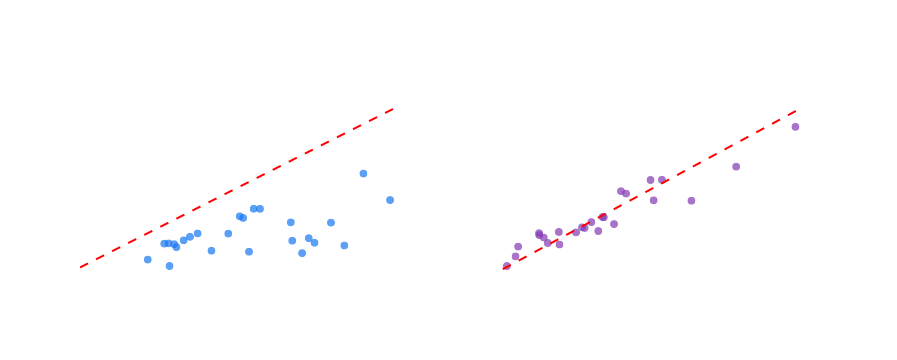

In [12]:
y_pred_ps_best = pipelines_ps[best_ps].predict(X_test)
y_pred_er_best = pipelines_er[best_er].predict(X_test)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=[f"Performance Score — {best_ps}",
                                    f"Engagement Rate — {best_er}"])

for col_data, y_test, y_pred, color, row in [
    ("ps", y_test_ps.values, y_pred_ps_best, BRAND_BLUE, 1),
    ("er", y_test_er.values, y_pred_er_best, BRAND_PURPLE, 2)
]:
    lims = [min(y_test.min(), y_pred.min())-0.5,
            max(y_test.max(), y_pred.max())+0.5]
    fig.add_trace(go.Scatter(x=y_test, y=y_pred, mode="markers",
        marker=dict(color=color, size=8, opacity=0.7)), row=1, col=row)
    fig.add_trace(go.Scatter(x=lims, y=lims, mode="lines",
        line=dict(color="red", dash="dash")), row=1, col=row)

fig.update_layout(
    title="Actual vs Predicted — Full Models",
    showlegend=False,
    plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)",
    font_color="rgba(255,255,255,0.8)"
)
fig.update_xaxes(title_text="Actual", row=1, col=1)
fig.update_xaxes(title_text="Actual", row=1, col=2)
fig.update_yaxes(title_text="Predicted", row=1, col=1)
fig.update_yaxes(title_text="Predicted", row=1, col=2)
fig.show()


## 9. 🚀 Pre-Publication Predictor

This section trains a **separate, cleaner model** using only features
available before publishing — no data leakage.

**Features excluded from predictor:**
- saves (82% zeros), comments (93% zeros), shares (74% zeros), follows (99% zeros)

**Default values:**
- reach=31 (median — mode only 6.5% of posts, not representative)
- views=84 (median — mode only 4.1% of posts, not representative)
- likes=4  (mode   — 24.4% of posts, representative)

The R² will be lower than the full model — this is expected and correct.
We are predicting with less information, which is the honest approach.


In [13]:
# Train predictor models
pred_mdf = df[PREDICTOR_ALL_FEATS + [ps_col, er_col]].dropna()
X_pred   = pred_mdf[PREDICTOR_ALL_FEATS]
y_pred_ps = pred_mdf[ps_col]
y_pred_er = pred_mdf[er_col]

pred_pre = build_preprocessor(PREDICTOR_NUM_FEATS, PREDICTOR_CAT_FEATS)
params   = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.8, random_state=RANDOM_STATE)

pred_pipe_ps = Pipeline([("pre", pred_pre), ("model", GradientBoostingRegressor(**params))])
pred_pipe_er = Pipeline([("pre", pred_pre), ("model", GradientBoostingRegressor(**params))])

pred_pipe_ps.fit(X_pred, y_pred_ps)
pred_pipe_er.fit(X_pred, y_pred_er)

cv_pred_ps = cross_val_score(pred_pipe_ps, X_pred, y_pred_ps, cv=cv, scoring="r2")
cv_pred_er = cross_val_score(pred_pipe_er, X_pred, y_pred_er, cv=cv, scoring="r2")

print("PREDICTOR MODEL PERFORMANCE (5-fold CV):")
print(f"   Performance Score : CV R²={cv_pred_ps.mean():.3f} ± {cv_pred_ps.std():.3f}")
print(f"   Engagement Rate   : CV R²={cv_pred_er.mean():.3f} ± {cv_pred_er.std():.3f}")
print()
print(f"Full model CV R² (Score): {results_ps[best_ps]['CV_R2']:.3f}")
print(f"Full model CV R² (ER)   : {results_er[best_er]['CV_R2']:.3f}")
print()
print("⚠️  Lower R² is expected and correct — we are predicting with")
print("   pre-publication data only. No data leakage.")


PREDICTOR MODEL PERFORMANCE (5-fold CV):
   Performance Score : CV R²=0.757 ± 0.088
   Engagement Rate   : CV R²=0.726 ± 0.122

Full model CV R² (Score): 0.892
Full model CV R² (ER)   : 0.866

⚠️  Lower R² is expected and correct — we are predicting with
   pre-publication data only. No data leakage.


In [14]:
# ── Fill in your post details here ────────────────────────────────────────
new_post = {}

# Numeric defaults — edit as needed for your specific post
new_post[meta.get("reach_col")] = 31    # median — change if expecting more/less reach
new_post[meta.get("views_col")] = 84    # median — change if expecting more/less views
new_post[meta.get("likes_col")] = 4     # mode   — change if expecting more/less likes

# Categorical — change to your planned post details
if type_col and type_col in PREDICTOR_CAT_FEATS:
    options = sorted(df[type_col].dropna().unique().tolist())
    new_post[type_col] = options[0]           # ← change to your content type
    print(f"Content type options: {options}")

if "weekday" in PREDICTOR_CAT_FEATS:
    best_day = df.groupby("weekday")[ps_col].mean().idxmax()
    new_post["weekday"] = best_day             # ← change to your planned day

if time_slot_col and time_slot_col in PREDICTOR_CAT_FEATS:
    best_slot = df.groupby(time_slot_col, observed=True)[ps_col].mean().idxmax()
    new_post[time_slot_col] = best_slot        # ← change to your planned slot

if "month" in PREDICTOR_CAT_FEATS:
    new_post["month"] = df["month"].mode()[0]

print("\nPost details:")
for k, v in new_post.items():
    print(f"   {str(k):30s}: {v}")


Content type options: ['IG carousel', 'IG image', 'IG reel', 'Post type']

Post details:
   reach                         : 31
   views                         : 84
   likes                         : 4
   post_type                     : IG carousel
   weekday                       : Tuesday
   time_slot                     : ☀️ Late Morning (10-12)
   month                         : June


In [15]:
# ── Run prediction ─────────────────────────────────────────────────────────
new_df  = pd.DataFrame([new_post])
pred_ps = max(0, pred_pipe_ps.predict(new_df)[0])
pred_er = max(0, pred_pipe_er.predict(new_df)[0])

avg_ps  = df[ps_col].mean()
avg_er  = df[er_col].mean()

print("=" * 60)
print("  PREDICTION RESULTS")
print("=" * 60)

print(f"\n  📊 Performance Score  : {pred_ps:.1f} / 100")
print(f"     Your avg Score     : {avg_ps:.1f} / 100")
print(f"     vs your avg        : {'✅ Above' if pred_ps >= avg_ps else '⚠️  Below'}  ({pred_ps-avg_ps:+.1f} pts)")

print(f"\n  📈 Engagement Rate    : {pred_er:.2f}%")
print(f"     Your avg ER        : {avg_er:.2f}%")
print(f"     Industry benchmark : {BENCHMARK_ER}%")
print(f"     vs your avg        : {'✅ Above' if pred_er >= avg_er else '⚠️  Below'}  ({pred_er-avg_er:+.2f}%)")

high_ps = pred_ps >= avg_ps
high_er = pred_er >= avg_er

print(f"\n  💡 INTERPRETATION:")
if high_ps and high_er:
    print(f"     🔥 STRONG POST — Publish and consider boosting!")
elif high_ps and not high_er:
    print(f"     📢 GOOD REACH — Add a strong CTA to drive more interactions.")
elif not high_ps and high_er:
    print(f"     🎯 GOOD ENGAGEMENT QUALITY — Consider boosting to amplify reach.")
else:
    print(f"     ⚠️  BELOW AVERAGE — Review content type, timing, or caption.")

print(f"\n  Predictor CV R² (Score): {cv_pred_ps.mean():.3f}")
print(f"  Predictor CV R² (ER)   : {cv_pred_er.mean():.3f}")
print(f"  Trained on             : {len(pred_mdf)} posts")
print("=" * 60)


  PREDICTION RESULTS

  📊 Performance Score  : 24.2 / 100
     Your avg Score     : 30.2 / 100
     vs your avg        : ⚠️  Below  (-6.1 pts)

  📈 Engagement Rate    : 14.58%
     Your avg ER        : 15.36%
     Industry benchmark : 5.0%
     vs your avg        : ⚠️  Below  (-0.78%)

  💡 INTERPRETATION:
     ⚠️  BELOW AVERAGE — Review content type, timing, or caption.

  Predictor CV R² (Score): 0.757
  Predictor CV R² (ER)   : 0.726
  Trained on             : 121 posts


In [17]:
# ── Sensitivity analysis ───────────────────────────────────────────────────
print("SENSITIVITY ANALYSIS")
print("How much does each input affect Performance Score?")
print()

base_ps      = pred_pipe_ps.predict(new_df)[0]
sensitivities = []

# Numeric: +50%
for col in PREDICTOR_NUM_FEATS:
    if new_post.get(col, 0) == 0:
        continue
    modified      = new_post.copy()
    modified[col] = new_post[col] * 1.5
    delta         = pred_pipe_ps.predict(pd.DataFrame([modified]))[0] - base_ps
    sensitivities.append((f"+50% {col}", delta))

# Categorical: best option
for col in PREDICTOR_CAT_FEATS:
    best_val = df.groupby(col, observed=True)[ps_col].mean().idxmax()
    if str(new_post.get(col)) == str(best_val):
        continue
    modified      = new_post.copy()
    modified[col] = best_val
    delta         = pred_pipe_ps.predict(pd.DataFrame([modified]))[0] - base_ps
    sensitivities.append((f"Best {col} ({best_val})", delta))

sensitivities.sort(key=lambda x: x[1], reverse=True)

for label, delta in sensitivities:
    arrow = "▲" if delta > 0 else "▼"
    bar   = "█" * max(1, int(abs(delta)))
    print(f"   {arrow} {abs(delta):.2f} pts  {label}  {bar}")

print()
print("→ Focus on the inputs with the highest positive impact.")


SENSITIVITY ANALYSIS
How much does each input affect Performance Score?

   ▲ 19.09 pts  +50% likes  ███████████████████
   ▲ 1.32 pts  +50% views  █
   ▼ 0.11 pts  Best post_type (IG reel)  █
   ▼ 0.37 pts  Best month (November)  █
   ▼ 2.19 pts  +50% reach  ██

→ Focus on the inputs with the highest positive impact.


## 10. Executive Summary

In [18]:
bm_ps = results_ps[best_ps]
bm_er = results_er[best_er]

print("=" * 65)
print("  MACHINE LEARNING SUMMARY — TRAVEL MEX TOURS")
print("=" * 65)

print(f"\n🏆 FULL MODEL (historical analysis)")
print(f"   Best model (Score): {best_ps}")
print(f"   R² Score          : {bm_ps['R2']}  ({bm_ps['R2']*100:.0f}% variance explained)")
print(f"   MAE               : ±{bm_ps['MAE']} points")
print(f"   CV R²             : {bm_ps['CV_R2']} ± {bm_ps['CV_R2_std']}")
print(f"   Best model (ER)   : {best_er}  (R²={bm_er['R2']})")

print(f"\n🎯 PREDICTOR MODEL (pre-publication only)")
print(f"   Features used     : {PREDICTOR_NUM_FEATS + PREDICTOR_CAT_FEATS}")
print(f"   CV R² (Score)     : {cv_pred_ps.mean():.3f} ± {cv_pred_ps.std():.3f}")
print(f"   CV R² (ER)        : {cv_pred_er.mean():.3f} ± {cv_pred_er.std():.3f}")
print(f"   Note              : Lower R² is correct — honest pre-publication prediction")

if fi_ps is not None:
    top_ps = fi_ps.iloc[0]["Feature"]
    print(f"\n🔑 TOP DRIVER OF PERFORMANCE SCORE: {top_ps}")

print(f"\n⚠️  MODEL LIMITATIONS")
print(f"   • Trained on {len(model_df)} posts — more data = better predictions")
print(f"   • Re-train monthly as new posts are published")
print(f"   • Predictor R² will improve as posting patterns diversify")

print(f"\n🎯 HOW TO USE")
print(f"   1. Before publishing → run Section 9 with your post details")
print(f"   2. Score < {avg_ps:.0f} (avg) → adjust content type, timing, or caption")
print(f"   3. Score ≥ {avg_ps:.0f} AND ER ≥ {avg_er:.1f}% → publish and boost")
print(f"   4. Upload new data monthly to keep model current")
print("=" * 65)
print("\n→ Next: Notebook 04 — Content Strategy")


  MACHINE LEARNING SUMMARY — TRAVEL MEX TOURS

🏆 FULL MODEL (historical analysis)
   Best model (Score): Gradient Boosting
   R² Score          : 0.9035  (90% variance explained)
   MAE               : ±2.9148 points
   CV R²             : 0.8923 ± 0.0573
   Best model (ER)   : Gradient Boosting  (R²=0.8883)

🎯 PREDICTOR MODEL (pre-publication only)
   Features used     : ['reach', 'views', 'likes', 'post_type', 'weekday', 'time_slot', 'month']
   CV R² (Score)     : 0.757 ± 0.088
   CV R² (ER)        : 0.726 ± 0.122
   Note              : Lower R² is correct — honest pre-publication prediction

🔑 TOP DRIVER OF PERFORMANCE SCORE: reach

⚠️  MODEL LIMITATIONS
   • Trained on 121 posts — more data = better predictions
   • Re-train monthly as new posts are published
   • Predictor R² will improve as posting patterns diversify

🎯 HOW TO USE
   1. Before publishing → run Section 9 with your post details
   2. Score < 30 (avg) → adjust content type, timing, or caption
   3. Score ≥ 30 AND E